# TEMPLATE MATCHING

### Simply looking for the exact copy of an image in another image

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
full = cv2.imread('../DATA/sammy.jpg')
full = cv2.cvtColor(full, cv2.COLOR_BGR2RGB)

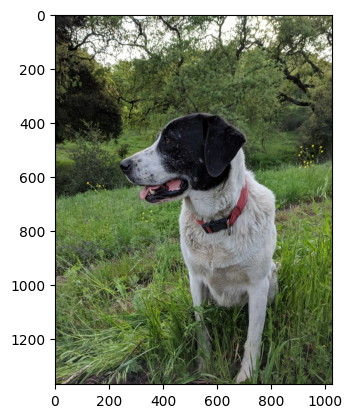

In [3]:
plt.imshow(full)

In [4]:
full.shape

(1367, 1025, 3)

In [5]:
face = cv2.imread('../DATA/sammy_face.jpg')
face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

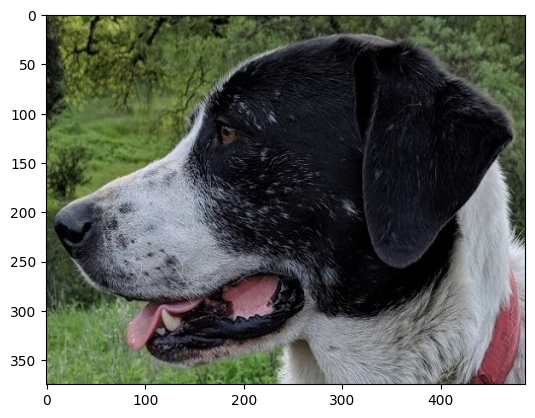

In [6]:
plt.imshow(face)

In [7]:
face.shape

(375, 486, 3)

In [8]:
# Finding the target image in pixel by pixel search manner, genrally we make use of six method.
# i.e, 'cv2.TM_CCOEFF', 'cv2.TM_'

In [9]:
# Storing all the methods in a list -> Using eval() method, list will be processed
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

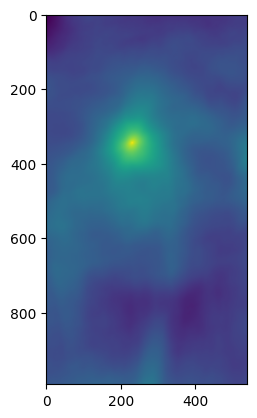

In [10]:
# While matching, it exactly gives us the heat map of maximum match by showing change in intensity of color.
method = eval('cv2.TM_CCOEFF')
res = cv2.matchTemplate(full, face, method)
plt.imshow(res)

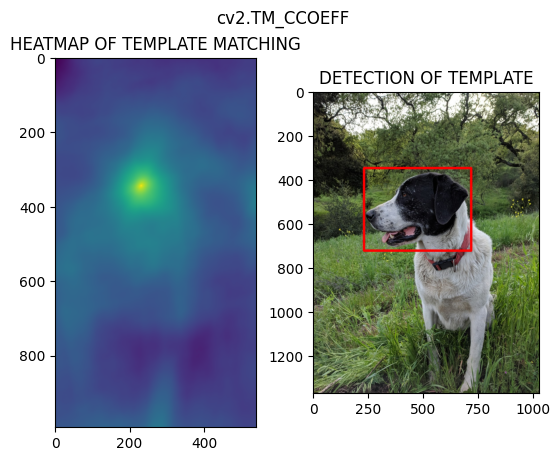

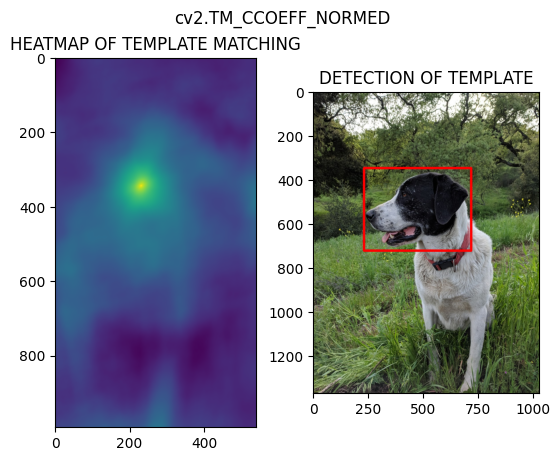

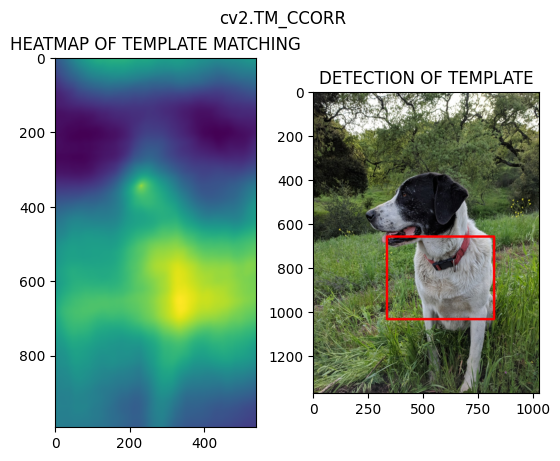

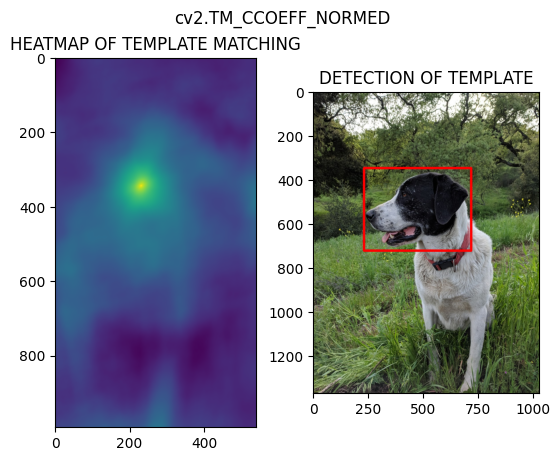

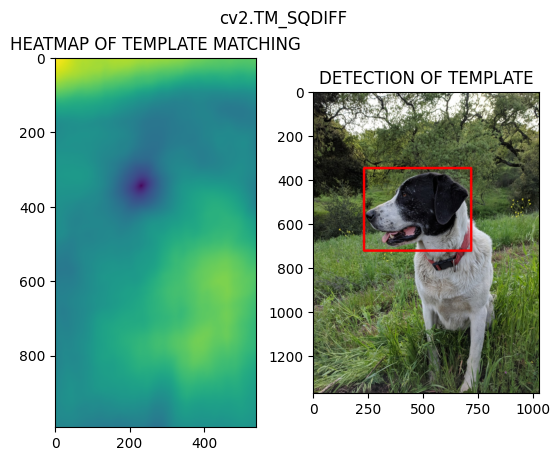

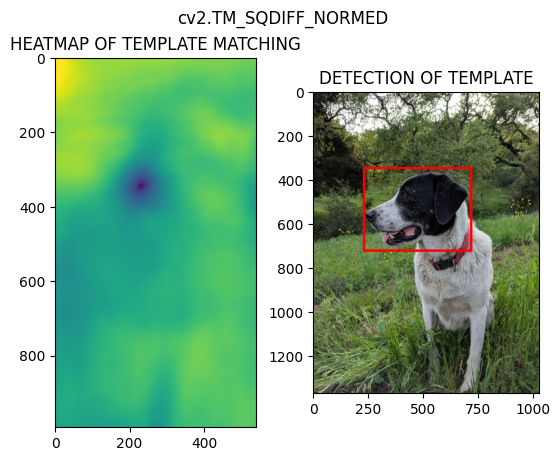

In [12]:
# Now, checking each method difference in matching result

for m in methods:
    # Create a copy
    full_copy = full.copy()

    method = eval(m)

    # TEMPLATE MATCHING
    res = cv2.matchTemplate(full_copy, face, method)

    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    height, width, channels = face.shape

    bottom_right = (top_left[0]+width, top_left[1]+height)

    cv2.rectangle(full_copy, top_left, bottom_right, (255, 0, 0), 10)

    # Plot and Show the images
    plt.subplot(121)
    plt.imshow(res)
    plt.title('HEATMAP OF TEMPLATE MATCHING')

    plt.subplot(122)
    plt.imshow(full_copy)
    plt.title('DETECTION OF TEMPLATE')
    # Title with the method used
    plt.suptitle(m)

    plt.show()

    print('\n')
    print('\n')